In [26]:
import os
import pandas as pd
import numpy as np
from PIL import Image

from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

In [27]:
df = pd.read_csv("HAM10000_metadata.csv")
print(df.head())

     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear


In [28]:

#we map all our 7 labels with indices from 0-6
label_map = {
    'mel': 0,
    'nv': 1,
    'bcc': 2,
    'akiec': 3,
    'bkl': 4,
    'df': 5,
    'vasc': 6
}

df['label'] = df['dx'].map(label_map)

In [29]:
IMAGE_FOLDERS = [
    "HAM10000_images_part_1",
    "HAM10000_images_part_2"
]

In [30]:
def find_image_path(image_id):
    for folder in IMAGE_FOLDERS:
        path = os.path.join(folder, image_id + ".jpg")
        if os.path.exists(path):
            return path
    return None

In [31]:
df['path'] = df['image_id'].apply(find_image_path)

# remove missing images (safety step)
df = df.dropna(subset=['path'])

In [32]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
 7   label         10015 non-null  int64  
 8   path          10015 non-null  object 
dtypes: float64(1), int64(1), object(7)
memory usage: 704.3+ KB


In [33]:
import os

missing = df['path'].apply(lambda x: not os.path.exists(x)).sum()
print(missing)

0


In [34]:
from sklearn.model_selection import train_test_split

In [47]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df['label'],
    random_state=42
)

In [48]:
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['label'],
    random_state=42
)

In [49]:
print(len(train_df), len(val_df), len(test_df))

8012 1001 1002


In [50]:
from torchvision import transforms

In [51]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

In [52]:
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [53]:

from torch.utils.data import Dataset
from PIL import Image

class SkinDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, 'path']
        label = self.df.loc[idx, 'label']

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [54]:
train_dataset = SkinDataset(train_df, train_transforms)
val_dataset = SkinDataset(val_df, val_transforms)
test_dataset = SkinDataset(test_df, val_transforms)

In [55]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [56]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])


In [57]:
print(labels[:10])

tensor([1, 1, 0, 1, 1, 0, 1, 1, 1, 4])


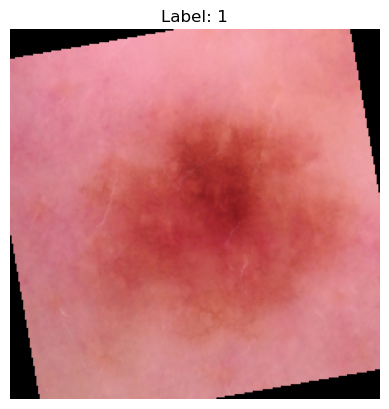

In [58]:
import matplotlib.pyplot as plt

img = images[0].permute(1, 2, 0)  # CHW → HWC

plt.imshow(img)
plt.title(f"Label: {labels[0].item()}")
plt.axis("off")
plt.show()